# Классификация качества красного вина с помощью SVC

В этом ноутбуке решается задача классификации вина на два класса:

- `bad wine` — если `quality < 6.5`
- `good wine` — если `quality > 6.5`

Так как исходный `quality` принимает целые значения от 3 до 8, условие эквивалентно:

- `bad wine`: `quality <= 6`
- `good wine`: `quality >= 7`

Что будет сделано:

1. Загрузка данных.
2. Первичный анализ и анализ распределений.
3. Анализ корреляций с исходным таргетом `quality`.
4. Категоризация целевой переменной.
5. Добавление новых признаков.
6. Масштабирование признаков через `StandardScaler()`.
7. Подбор гиперпараметров `SVC` через `Optuna`:
   - `C`
   - `gamma`
   - `kernel`
8. Оценка модели по `accuracy`.
9. Анализ `classification_report` и `confusion_matrix`.
10. Оценка лучшей модели на кросс-валидации.


## 1. Импорт библиотек

Загружаем библиотеки для работы с данными, графиками, масштабированием признаков, SVC и подбором гиперпараметров через `Optuna`.

Если `optuna` не установлена, ячейка попробует установить её автоматически.


In [1]:
import os
import sys
import zipfile
import warnings
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedShuffleSplit,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

try:
    import optuna
except ImportError:
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        'optuna'
    ])
    import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42


## 2. Загрузка данных

У датасета разделитель `;`, поэтому в `pd.read_csv()` указываем `sep=';'`.

In [2]:
df = pd.read_csv('data/winequality-red.zip', sep=';')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3. Первичный анализ данных

Посмотрим размер датасета, типы данных, базовые статистики и наличие пропусков.

In [3]:
print('Размер датасета:', df.shape)

display(df.info())
display(df.describe())

print('Количество пропусков в каждом столбце:')
display(df.isna().sum())

print('Распределение исходного качества вина:')
display(df['quality'].value_counts().sort_index())

Размер датасета: (1599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Количество пропусков в каждом столбце:


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Распределение исходного качества вина:


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

## 4. Анализ распределений признаков

Построим гистограммы для всех числовых признаков. Это закрывает часть задания про анализ распределений переменных.

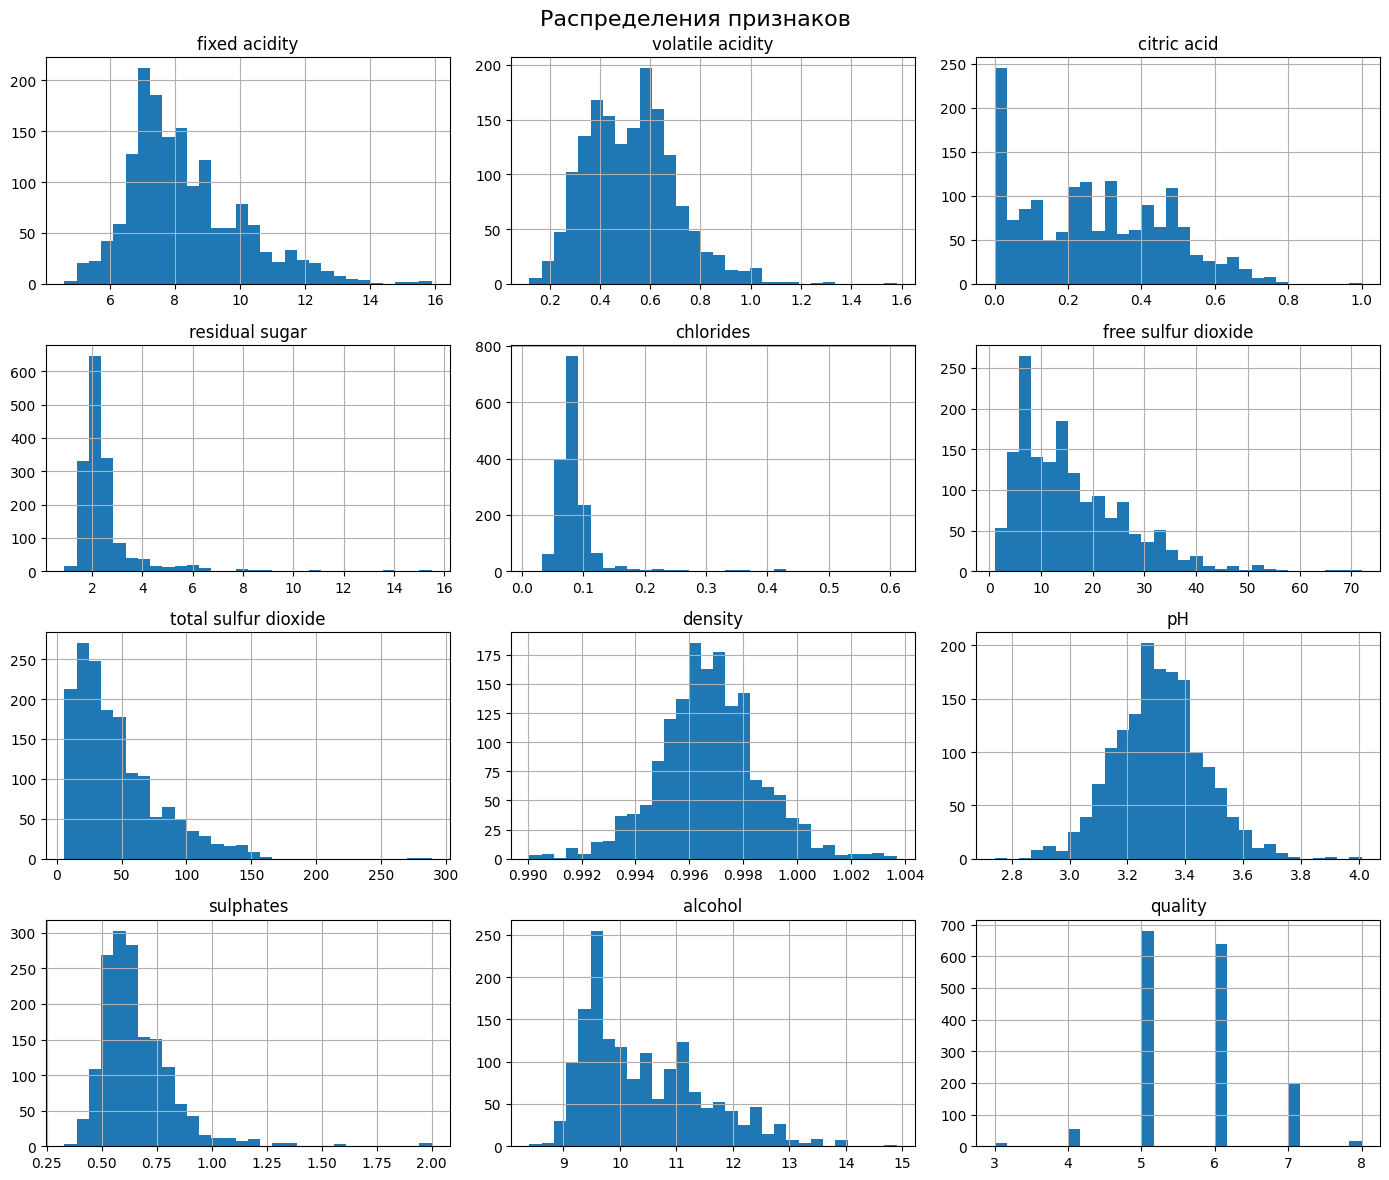

In [4]:
df.hist(
    figsize=(14, 12),
    bins=30
)

plt.suptitle('Распределения признаков', fontsize=16)
plt.tight_layout()
plt.show()

Отдельно посмотрим распределение исходного таргета `quality`.

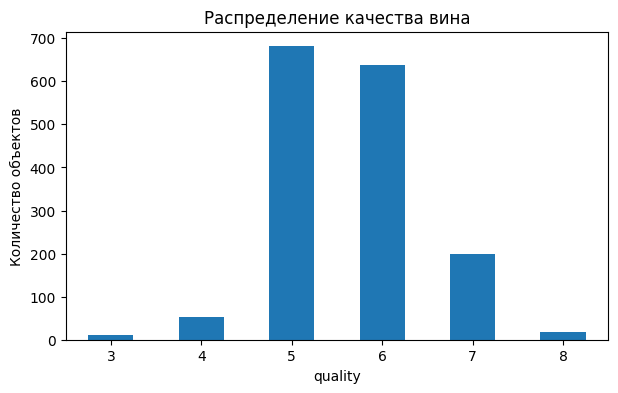

In [5]:
quality_counts = df['quality'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
quality_counts.plot(kind='bar')

plt.title('Распределение качества вина')
plt.xlabel('quality')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.show()

## 5. Корреляция признаков с таргетом

Посмотрим, какие признаки сильнее связаны с исходным числовым таргетом `quality`.

In [6]:
corr_with_quality = (
    df.corr(numeric_only=True)['quality']
    .sort_values(ascending=False)
)

display(corr_with_quality)

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

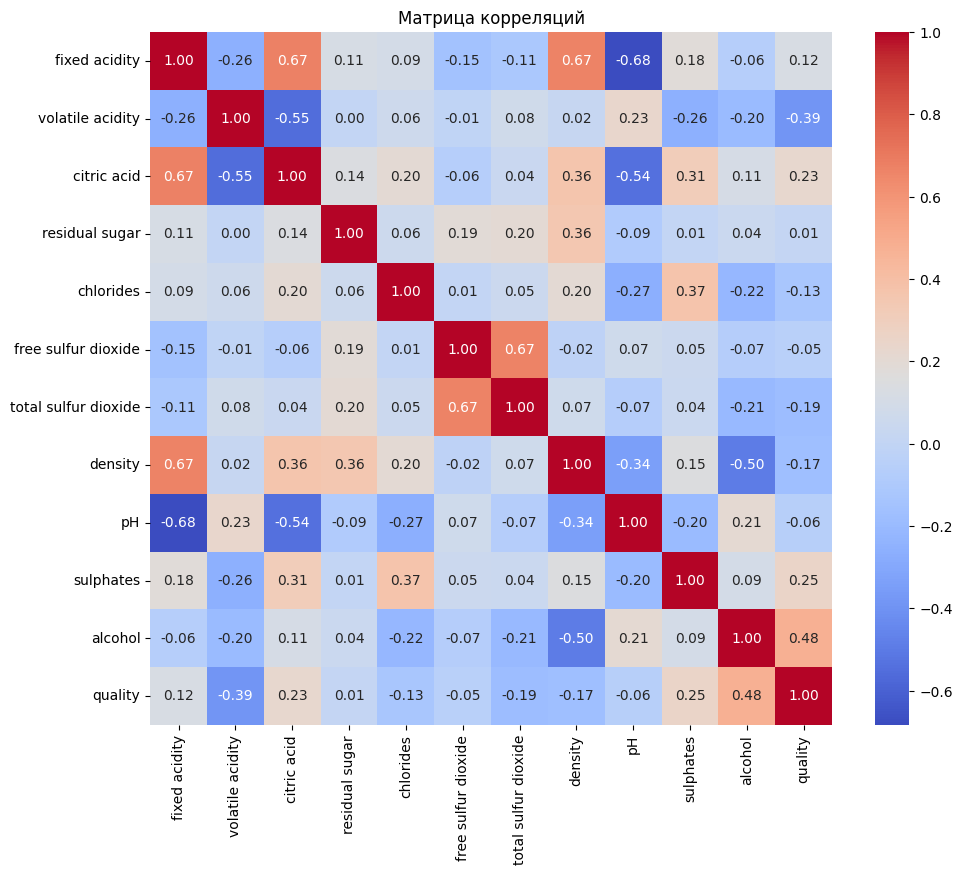

In [7]:
plt.figure(figsize=(11, 9))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Матрица корреляций')
plt.show()

По корреляциям обычно видно:

- `alcohol` сильнее всего положительно связан с качеством;
- `volatile acidity` отрицательно связана с качеством;
- `sulphates` и `citric acid` имеют положительную связь с качеством.

Корреляция показывает только линейную связь, поэтому далее используем SVC, который может строить и нелинейные границы.

## 6. Категоризация целевой переменной

По условию нужно сделать целевую переменную категориальной:

- `bad wine`, если `quality < 6.5`
- `good wine`, если `quality > 6.5`

Так как `quality` — целое число, получаем:

- `bad wine`: `quality <= 6`
- `good wine`: `quality >= 7`

Дополнительно кодируем целевую переменную:

- `0` — плохое вино
- `1` — хорошее вино

In [8]:
df['wine_class'] = np.where(
    df['quality'] > 6.5,
    'good wine',
    'bad wine'
)

df['target'] = np.where(
    df['quality'] > 6.5,
    1,
    0
)

display(df[['quality', 'wine_class', 'target']].head())

print('Распределение классов:')
display(df['wine_class'].value_counts())

print('Доли классов:')
display(df['wine_class'].value_counts(normalize=True))

,quality,wine_class,target
0,5,bad wine,0
1,5,bad wine,0
2,5,bad wine,0
3,6,bad wine,0
4,5,bad wine,0


Распределение классов:


wine_class
bad wine     1382
good wine     217
Name: count, dtype: int64

Доли классов:


wine_class
bad wine     0.86429
good wine    0.13571
Name: proportion, dtype: float64

## 7. Добавление новых признаков

Добавим несколько новых признаков на основе уже существующих.

Это помогает закрыть критерий: «Добавлены какие-либо новые признаки / категоризирован таргет».

In [9]:
df['total_acidity'] = (
    df['fixed acidity']
    + df['volatile acidity']
    + df['citric acid']
)

df['bound_sulfur_dioxide'] = (
    df['total sulfur dioxide']
    - df['free sulfur dioxide']
)

df['alcohol_sulphates'] = (
    df['alcohol']
    * df['sulphates']
)

df['sugar_alcohol_ratio'] = (
    df['residual sugar']
    / df['alcohol']
)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_class,target,total_acidity,bound_sulfur_dioxide,alcohol_sulphates,sugar_alcohol_ratio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,bad wine,0,8.10,23.0,5.264,0.202128
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,bad wine,0,8.68,42.0,6.664,0.265306
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,bad wine,0,8.60,39.0,6.370,0.234694
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,bad wine,0,12.04,43.0,5.684,0.193878
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,bad wine,0,8.10,23.0,5.264,0.202128


## 8. Подготовка признаков и целевой переменной

Из признаков обязательно удаляем:

- `quality`, потому что это исходный таргет;
- `wine_class`, потому что это текстовая версия нового таргета;
- `target`, потому что это целевая переменная.

Если оставить `quality` внутри `X`, получится утечка данных: модель будет видеть ответ во время обучения.

In [10]:
X = df.drop(
    columns=[
        'quality',
        'wine_class',
        'target'
    ]
)

y = df['target']

print('Размер X:', X.shape)
print('Размер y:', y.shape)

display(X.head())
display(y.head())

Размер X: (1599, 15)
Размер y: (1599,)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,total_acidity,bound_sulfur_dioxide,alcohol_sulphates,sugar_alcohol_ratio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,8.10,23.0,5.264,0.202128
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,8.68,42.0,6.664,0.265306
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,8.60,39.0,6.370,0.234694
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,12.04,43.0,5.684,0.193878
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,8.10,23.0,5.264,0.202128


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

## 9. Деление на train и validation

Используем стратификацию через `stratify=y`, чтобы соотношение классов в обучающей и валидационной выборках было похожим.

In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Train:', X_train.shape)
print('Validation:', X_valid.shape)

print('Распределение классов в train:')
display(y_train.value_counts(normalize=True))

print('Распределение классов в validation:')
display(y_valid.value_counts(normalize=True))

Train: (1279, 15)
Validation: (320, 15)
Распределение классов в train:


target
0    0.863956
1    0.136044
Name: proportion, dtype: float64

Распределение классов в validation:


target
0    0.865625
1    0.134375
Name: proportion, dtype: float64

## 10. Подбор гиперпараметров SVC через Optuna

По заданию нужно настроить:

- `C`
- `gamma`
- `kernel` из `['linear', 'poly', 'rbf', 'sigmoid']`

Также по условию используем `StandardScaler()` для преобразования признаков.

Важно: `StandardScaler()` помещён внутрь `Pipeline`. Это правильнее, чем скалировать весь датасет заранее, потому что при кросс-валидации scaler будет обучаться только на обучающей части каждого разбиения.

Вместо `GridSearchCV` используем `Optuna`. Она не перебирает все комбинации подряд, а подбирает параметры умнее: пробует разные значения и постепенно смещается к более удачным областям.

Для `linear`-ядра параметр `gamma` фактически не влияет на модель, но мы всё равно передаём его в `SVC`, чтобы в поиске явно участвовали все параметры из задания.


In [12]:
N_TRIALS = 50

cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=RANDOM_STATE
)


def objective(trial):
    kernel = trial.suggest_categorical(
        'kernel',
        [
            'linear',
            'poly',
            'rbf',
            'sigmoid'
        ]
    )

    C = trial.suggest_float(
        'C',
        1e-2,
        1e10,
        log=True
    )

    gamma = trial.suggest_float(
        'gamma',
        1e-9,
        1e3,
        log=True
    )

    model = Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('svc', SVC(
                kernel=kernel,
                C=C,
                gamma=gamma,
                random_state=RANDOM_STATE,
                cache_size=1000,
                max_iter=10000
            ))
        ]
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    return scores.mean()


sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE
)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print('Лучшие параметры Optuna:')
print(study.best_params)

print('Лучший accuracy на кросс-валидации внутри Optuna:')
print(study.best_value)

best_params = study.best_params

best_model = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('svc', SVC(
            kernel=best_params['kernel'],
            C=best_params['C'],
            gamma=best_params['gamma'],
            random_state=RANDOM_STATE,
            cache_size=1000,
            max_iter=10000
        ))
    ]
)

best_model.fit(X_train, y_train)

trials_df = study.trials_dataframe()
display(
    trials_df
    .sort_values('value', ascending=False)
    .head(10)
)


  0%|          | 0/50 [00:00<?, ?it/s]

Лучшие параметры Optuna:
{'kernel': 'rbf', 'C': 22140140.26141091, 'gamma': 0.8628410395837537}
Лучший accuracy на кросс-валидации внутри Optuna:
0.8875


,number,value,datetime_start,datetime_complete,duration,params_C,params_gamma,params_kernel,state
12,12,0.887500,2026-05-16 18:11:31.439086,2026-05-16 18:11:31.509055,0 days 00:00:00.069969,2.214014e+07,0.862841,rbf,COMPLETE
21,21,0.886719,2026-05-16 18:11:32.077810,2026-05-16 18:11:32.163914,0 days 00:00:00.086104,8.510851e+09,1.890866,rbf,COMPLETE
38,38,0.886719,2026-05-16 18:11:33.635356,2026-05-16 18:11:33.718378,0 days 00:00:00.083022,3.403081e+08,1.919747,rbf,COMPLETE
11,11,0.883594,2026-05-16 18:11:31.356777,2026-05-16 18:11:31.439086,0 days 00:00:00.082309,7.518434e+09,3.049057,rbf,COMPLETE
10,10,0.883594,2026-05-16 18:11:31.282221,2026-05-16 18:11:31.355742,0 days 00:00:00.073521,1.566125e+09,3.928095,rbf,COMPLETE
43,43,0.883594,2026-05-16 18:11:33.952766,2026-05-16 18:11:34.032675,0 days 00:00:00.079909,6.067410e+06,8.779674,rbf,COMPLETE
24,24,0.883594,2026-05-16 18:11:32.398159,2026-05-16 18:11:32.492328,0 days 00:00:00.094169,9.116475e+05,0.783138,rbf,COMPLETE
31,31,0.883594,2026-05-16 18:11:33.024946,2026-05-16 18:11:33.109899,0 days 00:00:00.084953,8.698613e+09,4.551404,rbf,COMPLETE
41,41,0.883594,2026-05-16 18:11:33.815408,2026-05-16 18:11:33.889714,0 days 00:00:00.074306,2.767127e+08,2.748921,rbf,COMPLETE
17,17,0.883594,2026-05-16 18:11:31.777695,2026-05-16 18:11:31.859361,0 days 00:00:00.081666,2.426064e+08,6.242654,rbf,COMPLETE


## 11. Оценка лучшей модели на validation

Теперь берём лучшую модель, найденную через `Optuna`, и проверяем её на отложенной валидационной выборке.


In [13]:
y_pred = best_model.predict(X_valid)

valid_accuracy = accuracy_score(y_valid, y_pred)

print('Accuracy на validation:', valid_accuracy)

print('Classification report:')
print(
    classification_report(
        y_valid,
        y_pred,
        target_names=[
            'bad wine',
            'good wine'
        ]
    )
)


Accuracy на validation: 0.921875
Classification report:
              precision    recall  f1-score   support

    bad wine       0.93      0.99      0.96       277
   good wine       0.88      0.49      0.63        43

    accuracy                           0.92       320
   macro avg       0.90      0.74      0.79       320
weighted avg       0.92      0.92      0.91       320



## 12. Confusion matrix

Матрица ошибок показывает, какие классы модель путает между собой.

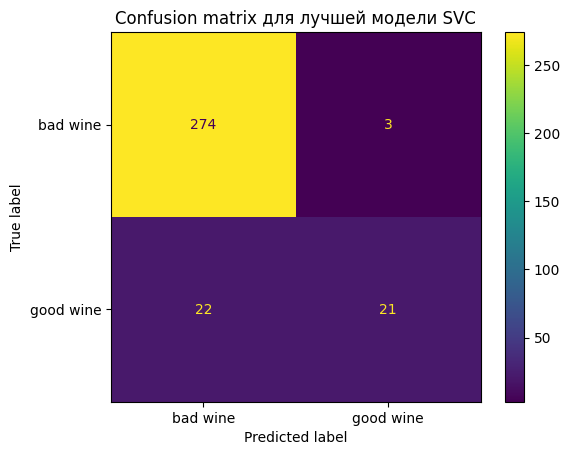

In [14]:
cm = confusion_matrix(y_valid, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'bad wine',
        'good wine'
    ]
)

disp.plot()
plt.title('Confusion matrix для лучшей модели SVC')
plt.show()

## 13. Дополнительная оценка лучшей модели на кросс-валидации

По заданию нужно обучить модель с лучшими параметрами и оценить `score` на кросс-валидации.

Используем `cross_val_score` с метрикой `accuracy`.

In [15]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=cv,
    scoring='accuracy',
    n_jobs=1
)

print('Accuracy на кросс-валидации:')
print(cv_scores)

print('Средний accuracy:', cv_scores.mean())
print('Стандартное отклонение:', cv_scores.std())

Accuracy на кросс-валидации:
[0.921875 0.896875 0.915625 0.91875  0.9     ]
Средний accuracy: 0.9106250000000001
Стандартное отклонение: 0.010193441518937552


## 14. Итоговый вывод

В работе выполнены все пункты задания:

1. Проведён анализ данных и распределений признаков.
2. Проанализирована корреляция признаков с исходным таргетом `quality`.
3. Целевая переменная преобразована в категориальную:
   - `bad wine`
   - `good wine`
4. Целевая переменная закодирована числами:
   - `0`
   - `1`
5. Добавлены новые признаки.
6. Использован `StandardScaler()` внутри `Pipeline`.
7. Выполнен подбор гиперпараметров `SVC` через `Optuna`:
   - `C`
   - `gamma`
   - `kernel`
8. Выбрано лучшее ядро.
9. Модель оценена по `accuracy`.
10. Построена `confusion_matrix`.
11. Лучшая модель дополнительно оценена на кросс-валидации.

Главный выбранный параметр для задания — это `kernel`, то есть ядро SVC. Его значение выводится в ячейке с `study.best_params`.
